In [1]:
%load_ext autoreload
%autoreload 2
# !hostname
# !pwd
import os, sys
# print(sys.executable)
# os.environ['CUDA_VISIBLE_DEVICES'] = "7"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = "false"
# sys.path.append(os.path.abspath(".."))

In [2]:
import os, sys, glob, pickle, copy, time
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = (15, 5)
import seaborn as sns
sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat
# from einop import einop

import jax
import jax.numpy as jnp
from jax.random import split

import flax
import flax.linen as nn
from flax.training.train_state import TrainState

import optax

import experiment_utils
import util
# from main import *
import plotstyle
plotstyle.set_plot_style()

In [3]:
# ! wget -P ./data https://pub.sakana.ai/asal/data/sweep_gol.npz

In [4]:
import frame_pred
argd = frame_pred.Args()

argd.n_iters = 100000
argd.log_every = 5000

argd.opt.weight_decay = 1e-5

args_all = []
seeds_all = range(1)
n_worlds_all = [10, 1000, 10000, 100000, 262144]
for seed in seeds_all:
    for n_worlds in n_worlds_all:
            args = copy.deepcopy(argd)
            args.seed = seed
            args.data.n_worlds = n_worlds

            args.save_dir = f"data/run_frame_pred_1/seed={seed}_n_worlds={n_worlds}"
            args_all.append(args)
            # print(args)
experiment_utils.create_commands(args_all, prefix="python frame_pred.py", out_file="science_scripts/frame_pred.sh");

In [10]:
df = []
for args in tqdm(args_all):
    main = frame_pred.Main(args)
    main.init()
    params = util.load_pkl(args.save_dir, "params")
    rng = jax.random.PRNGKey(0)

    batch = main.generate_batch(rng, train=True)
    rng, sub = split(rng)
    taus = jax.random.uniform(sub, 256, minval=0., maxval=1.)
    loss, (metrics, rng) = main.loss_fn(params, batch, taus, rng)
    y, pred = metrics['true_v'], metrics['pred_v']
    mse_train = float(((pred - y)**2).mean().item())

    batch = main.generate_batch(rng, train=False)
    rng, sub = split(rng)
    taus = jax.random.uniform(sub, 256, minval=0., maxval=1.)
    loss, (metrics, rng) = main.loss_fn(params, batch, taus, rng)
    y, pred = metrics['true_v'], metrics['pred_v']
    mse_test = float(((pred - y)**2).mean().item())
    
    dfi = dict(seed=args.seed, n_worlds=args.data.n_worlds, mse_train=mse_train, mse_test=mse_test)
    df.append(dfi)

df = pd.DataFrame(df)

  0%|          | 0/5 [00:00<?, ?it/s]

Args(seed=0, save_dir='data/run_frame_pred_1/seed=0_n_worlds=10', n_iters=100000, log_every=5000, model=ModelArgs(d_hidden=64), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=10, frames_per_param=4))



100%|██████████| 10/10 [00:01<00:00,  6.40it/s]


Computed normalization mean=0.23679199814796448, std=0.42511361837387085
Args(seed=0, save_dir='data/run_frame_pred_1/seed=0_n_worlds=1000', n_iters=100000, log_every=5000, model=ModelArgs(d_hidden=64), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=1000, frames_per_param=4))



100%|██████████| 100/100 [00:16<00:00,  6.20it/s]


...

Computed normalization mean=0.5196484327316284, std=0.49961382150650024
Args(seed=0, save_dir='data/run_frame_pred_1/seed=0_n_worlds=100000', n_iters=100000, log_every=5000, model=ModelArgs(d_hidden=64), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=100000, frames_per_param=4))



100%|██████████| 100/100 [00:16<00:00,  6.14it/s]


Computed normalization mean=0.540112316608429, std=0.4983883798122406
Args(seed=0, save_dir='data/run_frame_pred_1/seed=0_n_worlds=262144', n_iters=100000, log_every=5000, model=ModelArgs(d_hidden=64), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=262144, frames_per_param=4))



100%|██████████| 100/100 [00:15<00:00,  6.34it/s]


Computed normalization mean=0.5111083984375, std=0.49987661838531494


In [11]:
df

,seed,n_worlds,mse_train,mse_test
0,0,10,0.004902,0.006115
1,0,1000,0.012800,0.010415
2,0,10000,0.017941,0.016990
3,0,100000,0.023606,0.024254
4,0,262144,0.025242,0.025622


findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Fo

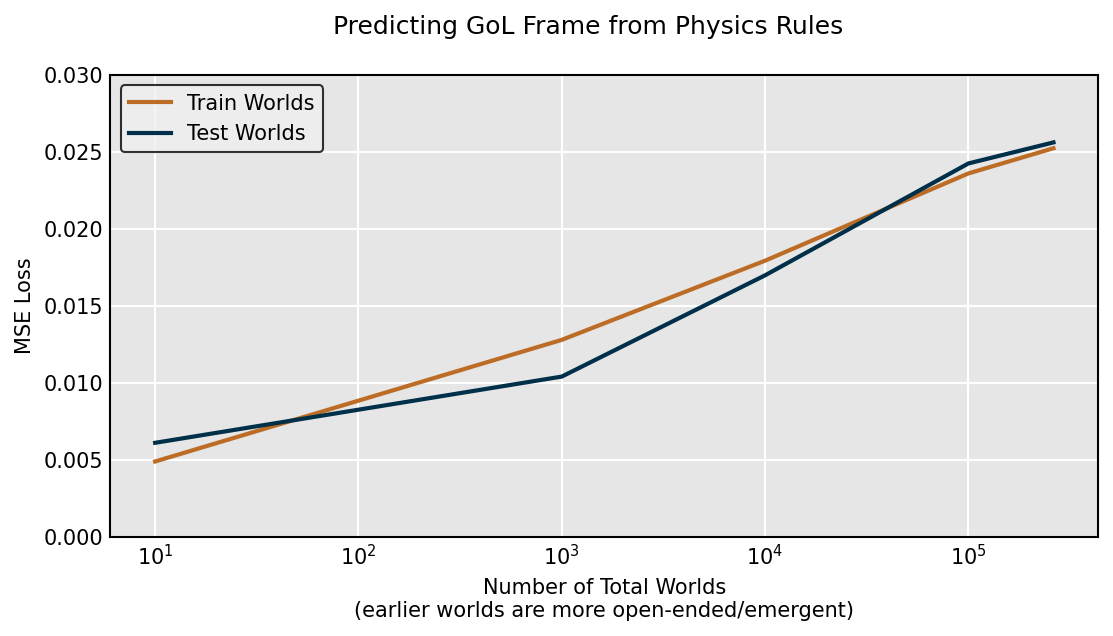

In [13]:
sns.lineplot(data=df, x='n_worlds', y='mse_train', label='Train Worlds', color='#bc6c25')
sns.lineplot(data=df, x='n_worlds', y='mse_test', label='Test Worlds', color='#003049')
plt.xlabel("Number of Total Worlds\n(earlier worlds are more open-ended/emergent)")
plt.ylabel("MSE Loss")
plt.suptitle("Predicting GoL Frame from Physics Rules")
plt.ylim(0.0, 0.03)
plt.xscale('log')
plt.legend()
plt.show()

In [5]:
args = args_all[0]

In [16]:
import copy
args = copy.deepcopy(args_all[0])
args.n_iters = 10000
print(args)

Args(seed=0, save_dir='data/run_frame_pred_1/seed=0_n_worlds=10', n_iters=10000, log_every=5000, model=ModelArgs(d_hidden=64), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=10, frames_per_param=4))


In [7]:
main = frame_pred.Main(args)
main.init()

Args(seed=0, save_dir='data/run_frame_pred_1/seed=0_n_worlds=10', n_iters=10000, log_every=5000, model=ModelArgs(d_hidden=128), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=10, frames_per_param=4))


100%|██████████| 10/10 [00:02<00:00,  3.63it/s]


Computed normalization mean=0.23679199814796448, std=0.42511361837387085


In [9]:
main.metrics.keys()

dict_keys(['gol_params', 'grads', 'loss', 'pred_v', 'true_v'])

In [10]:
main.run()

100%|██████████| 10000/10000 [21:06<00:00,  7.89it/s, loss=0.0121]


findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family ['Go'] not found. Falling back to DejaVu Sans.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font family 'Go' not found.
findfont: Font fami

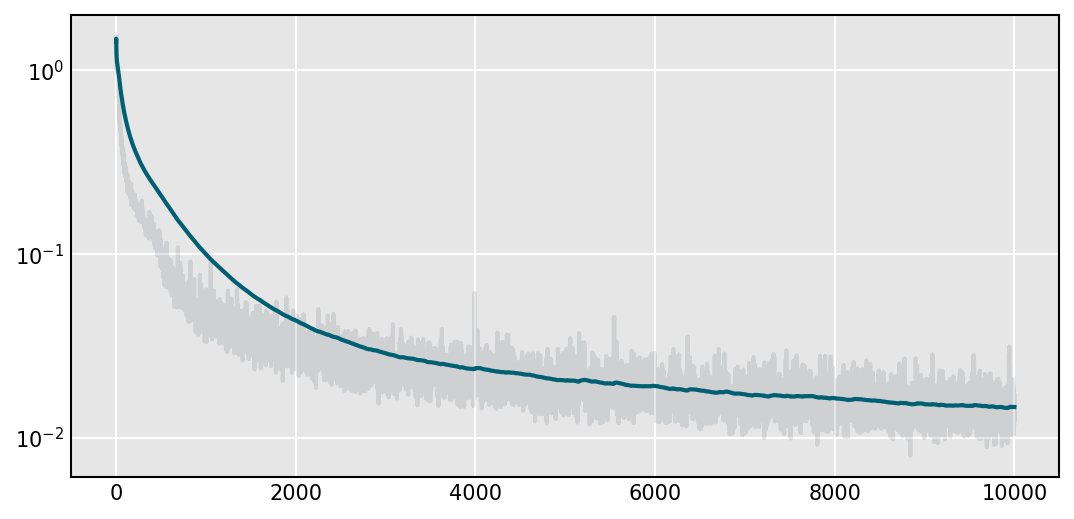

In [11]:
loss_history = util.load_pkl(args.save_dir, "loss_history")
plt.plot(loss_history, alpha=0.1)
loss_history = pd.DataFrame(loss_history).ewm(span=1000).mean()
plt.plot(loss_history)
# plt.axhline(y=9.0274756e-05, color='red')
# plt.axhline(y=4e-05, color='red')
plt.yscale('log')
# plt.ylim(8e-5, 1e-4)
# plt.ylim(1e-5, 1e-4)

In [12]:
params = util.load_pkl(args.save_dir, "params")
# params = main.train_state.params
# params = jax.tree.map(lambda x: jnp.zeros_like(x), params)

In [13]:
rng = jax.random.PRNGKey(0)
batch = main.generate_batch(rng, train=False)
rng, sub = split(rng)
taus = jax.random.uniform(sub, 256, minval=0., maxval=1.)
loss, (metrics, rng) = main.loss_fn(params, batch, taus, rng)

2025-07-20 16:11:36.408031: E external/xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv.1 = (f32[256,8,8,512]{3,2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %bitcast.7), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convForward", metadata={op_name="jit(conv_general_dilated)/jit(main)/conv_general_dilated" source_file="/usr/local/lib/python3.11/dist-packages/flax/linen/linear.py" source_line=695}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2025-07-20 16:11:37.006192: E external/xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.598291856s
Trying algorithm eng0{} for conv %cudnn-conv.1 = (f32[256,8,8,512]{3,2,1,0}, u8[0]{0}) custom-call(%Arg_0.1, %bitcast.7), window={size=3x3 pad

In [14]:
y, pred = metrics['true_v'], metrics['pred_v']
print(y.shape, pred.shape)

(256, 64, 64, 3) (256, 64, 64, 3)


In [6]:
main = frame_pred.Main(args)
main.create_normalizer()

Args(seed=0, save_dir='data/run_frame_pred_1/seed=0_n_worlds=10', n_iters=100000, log_every=5000, model=ModelArgs(d_hidden=64), opt=OptimizerArgs(batch_size=256, learning_rate=0.0003, weight_decay=1e-05, clip_grad_norm=1.0), data=DataArgs(grid_size=64, t_start=128, t_end=1024, batch_size=256, n_worlds=10, frames_per_param=4))


100%|██████████| 10/10 [00:02<00:00,  3.62it/s]


Computed normalization mean=0.23679199814796448, std=0.42511361837387085


In [7]:
params_np = util.load_pkl(args.save_dir, "params")
params = jax.tree.map(jnp.array, params_np)

In [12]:
gol_param_int = main.params_all[main.idx_train[0]]

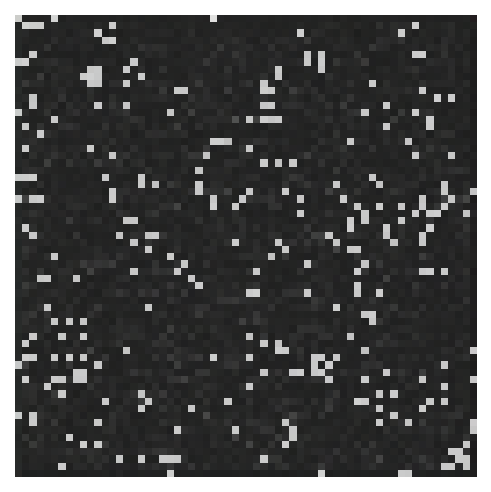

In [13]:
rng = jax.random.PRNGKey(args.seed)
frame = main.sample(params, gol_param_int, rng, n_steps=100)

import matplotlib.pyplot as plt
plt.imshow((frame.clip(0,1)))     # pixels range [0,1]
plt.axis('off')
plt.show()